In [2]:
# single-cell analysis package
library(Seurat)
library(SingleCellExperiment)
library(SummarizedExperiment)
library(Matrix)
library(edgeR)

# plotting and data science packages
library(purrr)
library(repr)
library(stringr)
library(dplyr) 
library(tidyverse)
library(ggplot2)
library(cowplot)
library(patchwork)

In [3]:
# Output Directory
outDir <- file.path("./results")

# load the unprocessed dataset
#scObj <- readRDS(file.path('./../data/HGSOC_All.rds'))
scObj <- readRDS(file.path('./../data/HGSOC_All.rds'))
print(scObj)
print(table(scObj@meta.data$Groups))

An object of class Seurat 
27157 features across 159682 samples within 1 assay 
Active assay: RNA (27157 features, 2000 variable features)
 2 layers present: counts, data
 2 dimensional reductions calculated: pca, umap

   Primary Tumor Metastatic Tumor       Lymph Node          Ascites 
           45146            21561            26449            38206 
            PBMC 
           28320 


In [4]:
# Select Primary tumor cells
filtered_barcode_index <- rownames(filter(scObj@meta.data, Groups == "Primary Tumor" ))
scObj <- subset(scObj, cells = filtered_barcode_index)
scObj@meta.data <- droplevels(scObj@meta.data)
print(scObj)
print(table(scObj@meta.data$maintypes))

An object of class Seurat 
27157 features across 45146 samples within 1 assay 
Active assay: RNA (27157 features, 2000 variable features)
 2 layers present: counts, data
 2 dimensional reductions calculated: pca, umap

    Stromal cells Endothelial cells      Cancer cells     Myeloid cells 
             5209               599             24849              8015 
   Lymphoid cells 
             6474 


In [5]:
# Select Cancer cells
filtered_barcode_index <- rownames(filter(scObj@meta.data, maintypes == "Cancer cells" ))
scObj <- subset(scObj, cells = filtered_barcode_index)
scObj@meta.data <- droplevels(scObj@meta.data)
print(scObj)
print(table(scObj@meta.data$Patients))

An object of class Seurat 
27157 features across 24849 samples within 1 assay 
Active assay: RNA (27157 features, 2000 variable features)
 2 layers present: counts, data
 2 dimensional reductions calculated: pca, umap

 HGSOC1  HGSOC2  HGSOC3  HGSOC4  HGSOC5  HGSOC6  HGSOC7  HGSOC8  HGSOC9 HGSOC10 
   3281    7709     959    2843    3296    1784     969    1092    1230    1686 


In [6]:
sensitive_patients <- c(
  "HGSOC1", "HGSOC2", "HGSOC4",
  "HGSOC5", "HGSOC8", "HGSOC9",  "HGSOC10"
)

resistant_patients <- c(
  "HGSOC3", "HGSOC6", "HGSOC7"
)

scObj$response <- ifelse(
  scObj$Patients %in% sensitive_patients,
  "Sensitive",
  ifelse(
    scObj$Patients %in% resistant_patients,
    "Resistant",
    NA
  )
)

scObj$response <- factor(
  scObj$response,
  levels = c("Sensitive", "Resistant")
)

table(scObj$response, scObj$Patients)

           
            HGSOC1 HGSOC2 HGSOC3 HGSOC4 HGSOC5 HGSOC6 HGSOC7 HGSOC8 HGSOC9
  Sensitive   3281   7709      0   2843   3296      0      0   1092   1230
  Resistant      0      0    959      0      0   1784    969      0      0
           
            HGSOC10
  Sensitive    1686
  Resistant       0

In [7]:
# ============================================================
# PRJCA005422
# Patient-level pseudobulk DE:
# Resistant vs Sensitive
# ============================================================


# ------------------------------------------------------------
# 1. Raw counts
# ------------------------------------------------------------

counts_all <- LayerData(
    scObj,
    assay = "RNA",
    layer = "counts"
)

# ------------------------------------------------------------
# 2. Validate metadata
# ------------------------------------------------------------

stopifnot(
    !anyNA(scObj$Patients),
    !anyNA(scObj$response)
)


scObj$Patients <- factor(scObj$Patients)

# ------------------------------------------------------------
# 3. Aggregate cells within patient
# ------------------------------------------------------------

patient <- factor(scObj$Patients)

patient_matrix <- Matrix::sparse.model.matrix(
    ~ 0 + patient
)

colnames(patient_matrix) <- levels(patient)

pb_counts <- counts_all %*% patient_matrix

dim(pb_counts)

# ------------------------------------------------------------
# 4. Patient-level metadata
# ------------------------------------------------------------

patient_metadata <- unique(
    scObj@meta.data[
        ,
        c("Patients", "response")
    ]
)

patient_metadata <- patient_metadata[
    match(
        colnames(pb_counts),
        patient_metadata$Patients
    ),
]

rownames(patient_metadata) <- patient_metadata$Patients

# Confirm count matrix and metadata alignment
stopifnot(
    all(
        colnames(pb_counts) ==
        patient_metadata$Patients
    )
)


[1] 27157    10

In [8]:
# ------------------------------------------------------------
# 5. Create edgeR object
# ------------------------------------------------------------

y <- DGEList(
    counts = pb_counts,
    samples = patient_metadata
)

y$samples$response <- factor(
    y$samples$response,
    levels = c("Sensitive", "Resistant")
)

In [9]:
# ------------------------------------------------------------
# 6. Inspect library sizes
# ------------------------------------------------------------

y$samples[
    ,
    c("response", "lib.size", "norm.factors")
]

# ------------------------------------------------------------
# 7. Filter genes using edgeR's pseudobulk filter
# ------------------------------------------------------------

keep <- filterByExpr(
    y,
    group = y$samples$response
)

table(keep)

y <- y[
    keep,
    ,
    keep.lib.sizes = FALSE
]

dim(y)

,response,lib.size,norm.factors
,<fct>,<dbl>,<dbl>
HGSOC1,Sensitive,63862937,1
HGSOC2,Sensitive,193656944,1
HGSOC3,Resistant,22906854,1
HGSOC4,Sensitive,23624783,1
HGSOC5,Sensitive,50434539,1
HGSOC6,Resistant,47329009,1
HGSOC7,Resistant,25499740,1
HGSOC8,Sensitive,25560296,1
HGSOC9,Sensitive,18372948,1


keep
FALSE  TRUE 
 9754 17403 

[1] 17403    10

In [10]:
# ------------------------------------------------------------
# 8. TMM normalization
# ------------------------------------------------------------

y <- calcNormFactors(y)

y$samples[
    ,
    c("response", "lib.size", "norm.factors")
]

,response,lib.size,norm.factors
,<fct>,<dbl>,<dbl>
HGSOC1,Sensitive,63782382,0.9537740
HGSOC2,Sensitive,193565176,0.9237644
HGSOC3,Resistant,22898929,0.9760696
HGSOC4,Sensitive,23559319,1.2284330
HGSOC5,Sensitive,50399135,1.1321104
HGSOC6,Resistant,47295202,0.8398518
HGSOC7,Resistant,25482738,1.1497388
HGSOC8,Sensitive,25545213,0.9871900
HGSOC9,Sensitive,18344166,1.2033254


In [11]:
# ------------------------------------------------------------
# 9. Design matrix
# ------------------------------------------------------------

design <- model.matrix(
    ~ response,
    data = y$samples
)

colnames(design)

[1] "(Intercept)"       "responseResistant"

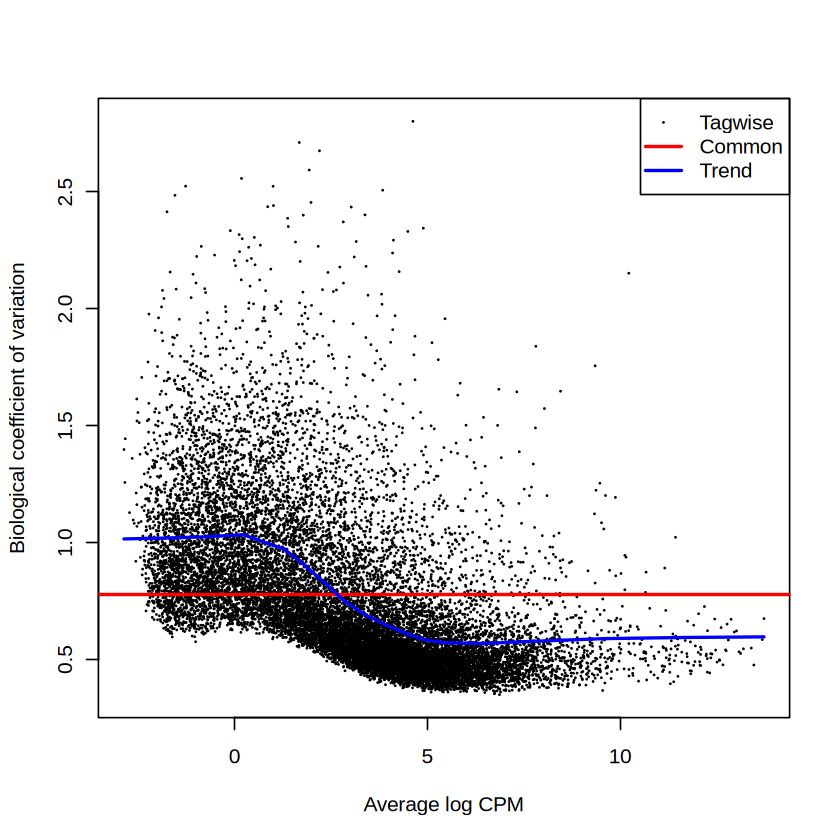

In [12]:
# ------------------------------------------------------------
# 10. Estimate dispersions
# ------------------------------------------------------------

y <- estimateDisp(
    y,
    design
)

# Optional diagnostic
plotBCV(y)

In [13]:
# ------------------------------------------------------------
# 11. Fit QL model
# ------------------------------------------------------------

fit <- glmQLFit(
    y,
    design,
    robust = TRUE
)

# ------------------------------------------------------------
# 12. Resistant vs Sensitive test
# ------------------------------------------------------------

qlf <- glmQLFTest(
    fit,
    coef = "responseResistant"
)
print(dim(qlf))

[1] 17403     4


In [14]:
# ------------------------------------------------------------
# 13. Extract complete results
# ------------------------------------------------------------

pb_results <- topTags(
    qlf,
    n = Inf
)$table
print(dim(pb_results))

pb_results$gene <- rownames(pb_results)

pb_results <- pb_results[
    ,
    c(
        "gene",
        "logFC",
        "logCPM",
        "F",
        "PValue",
        "FDR"
    )
]
print(dim(pb_results))

[1] 17403     5
[1] 17403     6


In [15]:
# ------------------------------------------------------------
# 14. Significant DEGs
# ------------------------------------------------------------

pb_results <- pb_results[
    order(pb_results$FDR),
]

pb_DEGs <- subset(
    pb_results,
    PValue < 0.05 &
    abs(logFC) > 0.5
)

# Resistant-associated
pb_resistant <- subset(
    pb_results,
    PValue < 0.05 &
    logFC > 0.5
)

# Sensitive-associated
pb_sensitive <- subset(
    pb_results,
    PValue < 0.05 &
    logFC < -0.5
)


# ------------------------------------------------------------
# 16. Basic summary
# ------------------------------------------------------------

cat(
    "Number of genes tested:",
    nrow(pb_results),
    "\n"
)

cat(
    "Number of DEGs at pvalue < 0.05 & abs(logFC) > 0.5:",
    nrow(pb_DEGs),
    "\n"
)

cat(
    "Resistant-up genes:",
    nrow(pb_resistant),
    "\n"
)

cat(
    "Sensitive-up genes:",
    nrow(pb_sensitive),
    "\n"
)

head(pb_results, 10)

Number of genes tested: 17403 
Number of DEGs at pvalue < 0.05 & abs(logFC) > 0.5: 809 
Resistant-up genes: 336 
Sensitive-up genes: 473 


,gene,logFC,logCPM,F,PValue,FDR
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
REG1A,REG1A,7.660154,4.37529986,46.38830,1.137924e-05,0.1947429
CRYM,CRYM,3.873289,-1.40909210,29.38830,2.238039e-05,0.1947429
BTBD11,BTBD11,3.340843,-1.66548112,25.76897,5.139688e-05,0.2595664
SCGB1C2,SCGB1C2,4.418915,-0.03722045,27.47811,5.966015e-05,0.2595664
RP11-400N13.2,RP11-400N13.2,5.035422,1.37844721,28.41467,9.153188e-05,0.3185859
KCNJ16,KCNJ16,3.959676,0.79608434,26.41861,1.544713e-04,0.3783694
LINC01502,LINC01502,3.083510,-1.41951906,21.60493,1.722486e-04,0.3783694
TP53,TP53,-3.844385,4.39048921,27.42368,1.739330e-04,0.3783694
FAM150A,FAM150A,4.123920,-0.98320614,20.31697,2.040634e-04,0.3945906


In [16]:
# ------------------------------------------------------------
# 15. Save results
# ------------------------------------------------------------

# write.csv(
#     pb_results,
#     "./results/PRJCA005422_pseudobulk_edgeR_results.csv",
#     row.names = FALSE
# )

# write.csv(
#     pb_DEGs,
#     "./results/PRJCA005422_pseudobulk_edgeR_DEGs_PValue05.csv",
#     row.names = FALSE
# )

# write.csv(
#     pb_resistant,
#     "./results/PRJCA005422_pseudobulk_resistant_DEGs_PValue05.csv",
#     row.names = FALSE
# )

# write.csv(
#     pb_sensitive,
#     "./results/PRJCA005422_pseudobulk_sensitive_DEGs_PValue05.csv",
#     row.names = FALSE
# )


## Plot

In [18]:
library(pheatmap)

In [19]:
# ---------------------------------------------------------
# 1. Select top 25 upregulated and top 25 downregulated genes
# ---------------------------------------------------------

# Upregulated in Resistant
top_up <- head(pb_resistant, 25)

# Downregulated in Resistant
top_down <- head(pb_sensitive, 25)

# Combined list
top_genes <- c(
  top_up$gene,
  top_down$gene
)

# Remove duplicates just in case
top_genes <- unique(top_genes)

length(top_genes)

[1] 50

In [20]:
logCPM <- cpm(
  y,
  log = TRUE,
  prior.count = 1
)

heatmap_mat <- logCPM[top_genes, , drop = FALSE]
heatmap_mat_z <- t(scale(t(heatmap_mat)))

In [21]:
annotation_col <- data.frame(
  Response = y$samples$response
)

rownames(annotation_col) <- y$samples$Patients

In [22]:
annotation_col <- annotation_col[colnames(heatmap_mat_z), , drop = FALSE]

In [23]:
patient_order <- rownames(
  annotation_col[
    order(annotation_col$Response),
    ,
    drop = FALSE
  ]
)

heatmap_mat_z <- heatmap_mat_z[, patient_order, drop = FALSE]

annotation_col <- annotation_col[
  patient_order,
  ,
  drop = FALSE
]

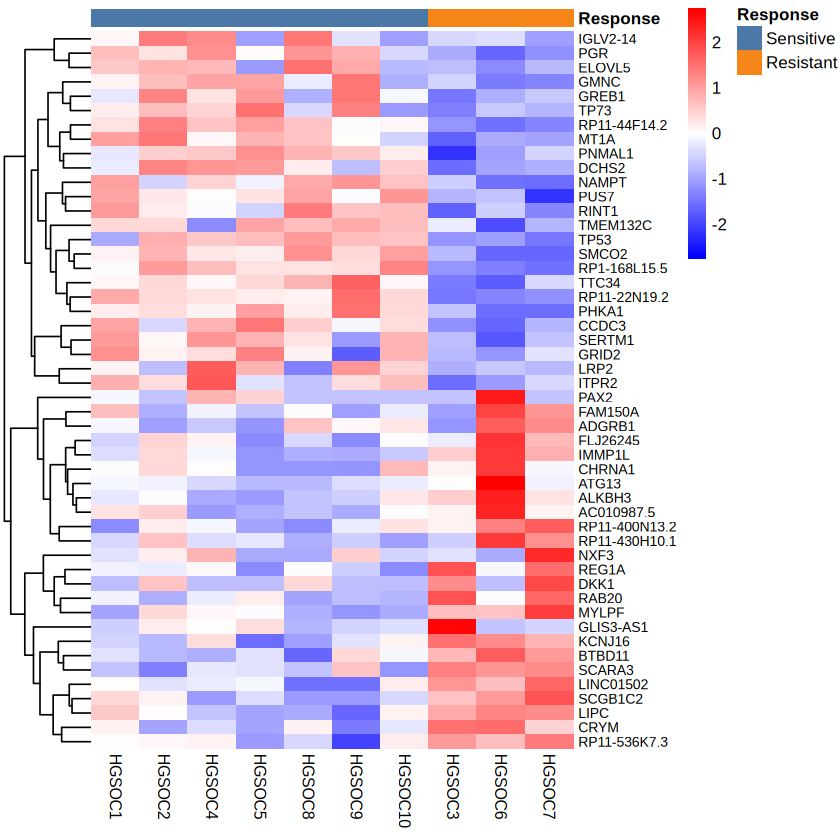

In [24]:
# Make the color range symmetric around zero
max_abs <- max(abs(heatmap_mat_z), na.rm = TRUE)

# Blue -> white -> red
my_colors <- colorRampPalette(
  c("blue", "white", "red")
)(100)

annotation_colors <- list(
  Response = c(
    Sensitive = "#4C78A8",
    Resistant = "#F58518"
  )
)


p <- pheatmap(
  heatmap_mat_z,
  scale = "none",
  color = my_colors,
  # Force white to correspond to 0
  breaks = seq(-max_abs, max_abs, length.out = 101),
  cluster_rows = TRUE,
  cluster_cols = FALSE,
  annotation_col = annotation_col,
  annotation_colors = annotation_colors,
  show_rownames = TRUE,
  show_colnames = TRUE,
  fontsize_row = 8,
  fontsize_col = 9,
  border_color = NA,
  #main = "Top 25 Up- and Downregulated Genes"
)

In [25]:
#options(repr.plot.height = 10, repr.plot.width = 10)

png(filename = "./results/PRJCA005422_pseudoBulk_TopDEGs.png", width = 1800, height = 2100, res = 300)

p

dev.off()

pdf 
  2